In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("laptop_data.csv")
df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [7]:
print(X.columns)

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight'],
      dtype='object')


In [3]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

X = df.drop("Price", axis=1)
y = df["Price"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
model = DecisionTreeRegressor(max_depth=5)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.6989065563861865


In [14]:
import pandas as pd

# User Input
unnamed = int(input("Unnamed: 0 : "))

company = int(input("Company: "))
typename = int(input("TypeName: "))
inches = float(input("Inches: "))
screen = int(input("ScreenResolution: "))
cpu = int(input("Cpu: "))
ram = int(input("Ram: "))
memory = int(input("Memory: "))
gpu = int(input("Gpu: "))
opsys = int(input("OpSys: "))
weight = float(input("Weight: "))

# Create DataFrame with SAME columns and SAME order as training data
new_laptop = pd.DataFrame({
    'Unnamed: 0': [unnamed],
    'Company': [company],
    'TypeName': [typename],
    'Inches': [inches],
    'ScreenResolution': [screen],
    'Cpu': [cpu],
    'Ram': [ram],
    'Memory': [memory],
    'Gpu': [gpu],
    'OpSys': [opsys],
    'Weight': [weight]
})

# Prediction
price = model.predict(new_laptop)

print("Predicted Price = ₹", round(price[0], 2))

Unnamed: 0 : 0
Company: 1
TypeName: 2
Inches: 15.6
ScreenResolution: 3
Cpu: 4
Ram: 8
Memory: 512
Gpu: 2
OpSys: 1
Weight: 2.1
Predicted Price = ₹ 61074.81


In [15]:
new_laptop = pd.DataFrame({
    'Unnamed: 0':[0],
    'Company':[company],
    'TypeName':[typename],
    'Inches':[inches],
    'ScreenResolution':[screen],
    'Cpu':[cpu],
    'Ram':[ram],
    'Memory':[memory],
    'Gpu':[gpu],
    'OpSys':[opsys],
    'Weight':[weight]
})
price = model.predict(new_laptop)

print("Predicted Price = ₹", round(price[0], 2))

Predicted Price = ₹ 61074.81


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [17]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [22]:
print(X.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [19]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)


In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315

Confusion Matrix:
[[40  3]
 [ 3 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



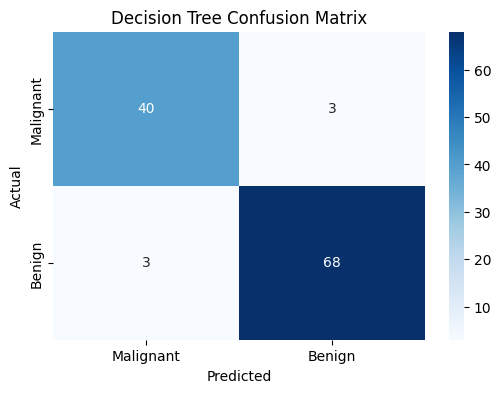

In [21]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant','Benign'],
    yticklabels=['Malignant','Benign']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [23]:
import pandas as pd

feature_names = [
    'mean radius', 'mean texture', 'mean perimeter', 'mean area',
    'mean smoothness', 'mean compactness', 'mean concavity',
    'mean concave points', 'mean symmetry', 'mean fractal dimension',
    'radius error', 'texture error', 'perimeter error', 'area error',
    'smoothness error', 'compactness error', 'concavity error',
    'concave points error', 'symmetry error', 'fractal dimension error',
    'worst radius', 'worst texture', 'worst perimeter', 'worst area',
    'worst smoothness', 'worst compactness', 'worst concavity',
    'worst concave points', 'worst symmetry', 'worst fractal dimension'
]

user_data = []

for feature in feature_names:
    value = float(input(f"Enter {feature}: "))
    user_data.append(value)

new_patient = pd.DataFrame([user_data], columns=feature_names)

prediction = model.predict(new_patient)

if prediction[0] == 0:
    print("Malignant Cancer")
else:
    print("Benign Cancer")

Enter mean radius: 17.99
Enter mean texture: 10.38
Enter mean perimeter: 112.8
Enter mean area: 1001.0
Enter mean smoothness: 0.1184
Enter mean compactness: 0.2776
Enter mean concavity: 0.3001
Enter mean concave points: 0.1471
Enter mean symmetry: 0.2419
Enter mean fractal dimension: 0.07871
Enter radius error: 1.095
Enter texture error: 0.9053
Enter perimeter error: 8.589
Enter area error: 153.4
Enter smoothness error: 0.006399
Enter compactness error: 0.04904
Enter concavity error: 0.05373
Enter concave points error: 0.01587
Enter symmetry error: 0.03003
Enter fractal dimension error: 0.006193
Enter worst radius: 25.38
Enter worst texture: 17.33
Enter worst perimeter: 184.6
Enter worst area: 2019.0
Enter worst smoothness: 0.1622
Enter worst compactness: 0.6656
Enter worst concavity: 0.7119
Enter worst concave points: 0.2654
Enter worst symmetry: 0.4601
Enter worst fractal dimension: 0.1189
Malignant Cancer


In [24]:
prediction = model.predict(new_patient)

labels = {
    0: "Malignant",
    1: "Benign"
}

print("Prediction:", labels[prediction[0]])

Prediction: Malignant
